# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos:\n", users.isna().sum()) # Cantidad de valores nulos)
print("\nProporción de valores nulos:\n", users.isna().mean()) # Proporción de valores nulos)

Cantidad de valores nulos:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:\n", usage.isna().sum())
print("\nProporción de valores nulos:\n", usage.isna().mean()) 

Cantidad de valores nulos:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

DIAGNÓSITICO:

usage
- DATE (0.13% nulos): proporción mínima. Se eliminan esas filas o se dejan como nulas, sin impacto real.
- DURATION (55.19% nulos): no es un dato faltante, es estructural; se deja como está, no imputar.
- LENGHT (44.74% nulos): mismo caso que duration pero para type == "text"; se deja como está, no imputar.


users
- CITY (11.73% nulos): rango medio, requiere investigar: imputar con categoría "Desconocido" o excluir solo en análisis geográficos.
- CHURN_DATE (88.35% nulos): el nulo no es un error, indica cliente activo: no eliminar/imputar, usar para crear variable binaria "is_churned".


plans

Sin valores nulos, no requiere acción.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**I
nstrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users[['user_id', 'age']].describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` observamos los números de identificación de cada cliente, van del 10000 al 13999. Estos datos son útiles solo para diferenciar a cada persona.
- La columna `age` Podemos identificar que el valor mínimo es -999, lo que hace que el promedio (33.7) y la mediana (47) no coincidan. Se confirma que ese valor está distorsionando las operaciones y requiere correción.

In [13]:
usage[['id', 'user_id', 'duration', 'length']].describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son identificadores para registro de uso y de cliente. Sirven para identificar filas y usuarios. Los valores parecen estar en forma.
- La columna `duration` muestra que el mínimo es 0, lo cual tiene sentido si fue una llamada no contestada o muy corta. El máximo es 120 minutos, una llamada larga pero no imposible.
- La columna `lenght` muestra la cantidad de caracteres en los mensajes de texto. El mínimo es 0 y el máximo es 1490, lo cual insinúa un número bastante alto para un solo mensaje. Requiere revisión.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- {col} ---")
    print(users[col].value_counts(dropna=False))
    print() 

--- city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` muestra que además de los 469 casos que ya sabíamos vacíos (NaN), hay 96 registros con un signo de interrogación "?", lo cual insinúa datos faltantes posiblemente en formato texto. Requiere revisión.
- La columna `plan` cuenta únicamente dos tipos de valores sin alteraciones aparentes. No requiere revisión.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` presenta únicamente dos valores sin alteraciones. No requiere revisión.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

- `age` (users): el valor mínimo es -999, lo cual es imposible para una edad. Es un sentinel: un valor centinela usado para representar "dato desconocido" en lugar de un NaN explícito. Esto se confirma al comparar la media (33.7) con la mediana (47): la diferencia tan grande indica que el -999 está arrastrando el promedio hacia abajo.
- `city` (users): además de los 469 valores NaN ya identificados, hay 96 registros con el valor "?", que funciona como un sentinel de texto para "sin información". No lo detectamos antes con `.isna()` porque no es un nulo real, es un string.
- `length` (usage): no es un sentinel confirmado, pero el máximo de 1490 caracteres es un valor atípico que vale la pena marcar para revisión (podría tratarse de un error de captura).


- ¿Qué acción tomarías?

- `age`: reemplazar -999 por NaN con `.replace()` y luego decidir si se imputa o se deja como nulo, dependiendo del porcentaje resultante.
- `city`: reemplazar "?" por NaN con `.replace()` para unificarlo con los nulos ya existentes, y tratarlo con la misma estrategia que se decida para esa columna.
- `length`: no aplicar ninguna corrección todavía. Dejarlo documentado como posible outlier y revisarlo más adelante con un boxplot o percentiles antes de decidir si se trata como error o como dato válido.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index() 

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, la mayoría de los registros se concentran en 2022, 2023 y 2024, con una cantidad bastante pareja entre esos tres años, lo cual tiene sentido. Sin embargo habría que explorar la veracidad de los datos en el año 2026 y descartar un posible error de captura.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index() 

2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros corresponden al año 2024, que es justo el rango esperado. No se detectan años fuera de rango en esta columna.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Sí, mas no en usage. En reg_date de users aparecen 40 registros con año 2026, un año que aún no ha transcurrido respecto al periodo de datos del proyecto. En date de usage no aparecen años imposibles, todos son 2024.
- ¿Qué harías con ellas? Trataría los 40 registros de reg_date con año 2026 como fechas inválidas: los reemplazaría por NaT usando una condición, en lugar de eliminar directamente esas filas, ya que el resto de la información del usuario sigue siendo válida y útil para el análisis. Así conservamos las filas pero dejamos claro que ese dato puntual no es del todo confiable.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median() 
users['age'] =users['age'].replace(-999, age_mediana) 

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index() 

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(usage['type'], usage['duration'].isna()) 

duration,False,True
type,,
call,17908,0
text,16,22076


In [24]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(usage['type'], usage['length'].isna())

length,False,True
type,,
call,12,17896
text,22092,0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`:

Al cruzar cada columna con type, se confirma que el patrón es MAYORITARIAMENTE dependiente de type, pero no perfecto al 100%:

El patrón es mayoritariamente MAR según type, pero no perfecto: 16 filas text tienen duration y 12 filas call tienen length. Son 28 de 40,000 filas, posible error de etiquetado en type.

Decisión: los nulos "normales" se dejan como NaN. Las 28 filas inconsistentes se marcan para revisión aparte, sin corregir aún.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

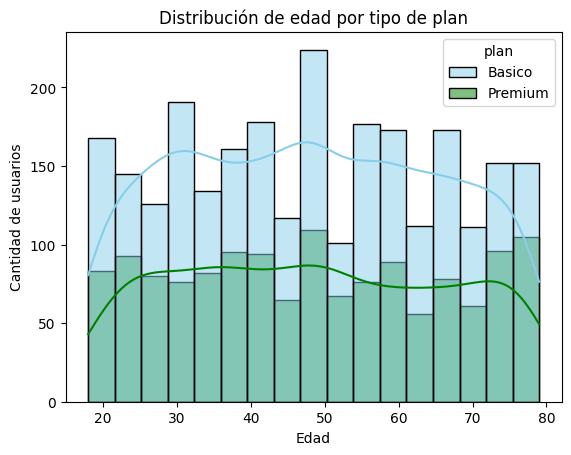

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 

- La distribución de edad es bastante uniforme entre los 18 y 80 años, sin un pico dominante ni sesgo marcado hacia algún grupo etario.
- En todos los rangos de edad, el plan Básico tiene aproximadamente el doble de usuarios que el plan Premium, una proporción consistente que coincide con el ~65%/35% visto en la distribución general de planes. No hay un grupo etario particular que prefiera Premium sobre Básico.

Text(0, 0.5, 'Cantidad de usuarios')

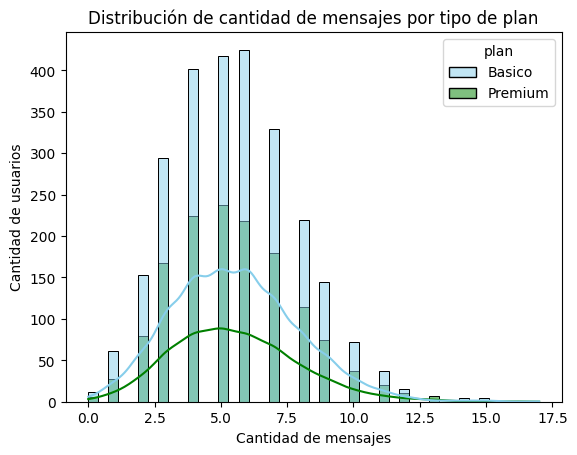

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')

💡Insights: 
- La distribución está sesgada a la derecha: la mayoría de los usuarios envía entre 4 y 7 mensajes, con pocos casos que llegan a 15+.
- El plan Básico domina en cantidad de usuarios en cada barra, pero la forma de la distribución es similar entre ambos planes. No hay evidencia de que un plan envíe sistemáticamente más o menos mensajes que el otro en proporción.

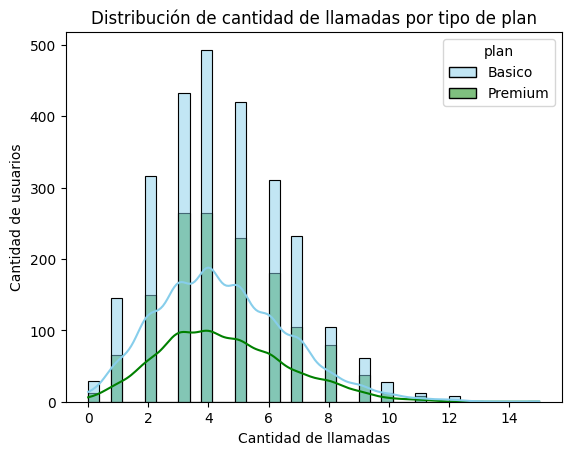

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha, con pico entre 3 y 5 llamadas y una cola que se extiende hasta 14, similar en forma a la de mensajes.
- Al igual que con mensajes, la proporción basico/premium se mantiene constante en cada barra, sugiriendo que el tipo de plan no está asociado con hacer más o menos llamadas.

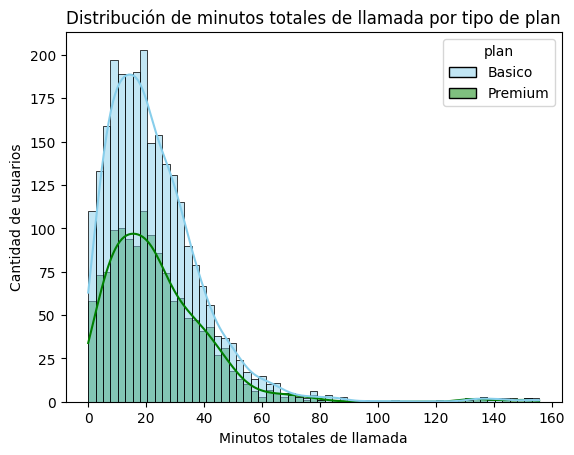

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de minutos totales de llamada por tipo de plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución claramente sesgada a la derecha: la mayoría de los usuarios acumula entre 10 y 30 minutos totales de llamada, pero hay una cola larga de casos que llegan hasta 160 minutos — posibles usuarios "power users" de llamadas.
- El patrón se repite: no hay diferencia notable en la forma de la distribución entre Básico y Premium, solo en la cantidad absoluta de usuarios.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

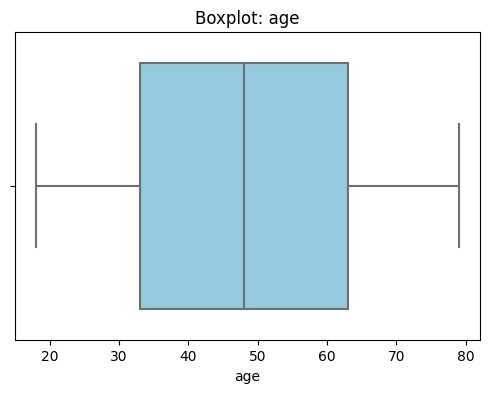

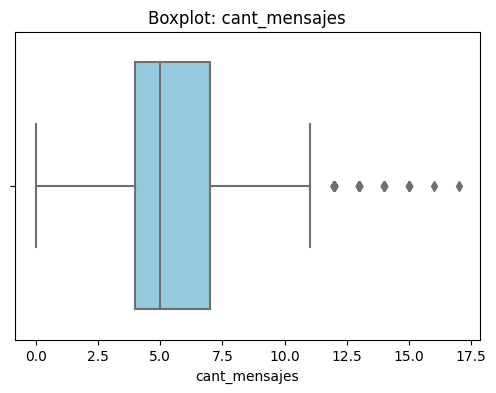

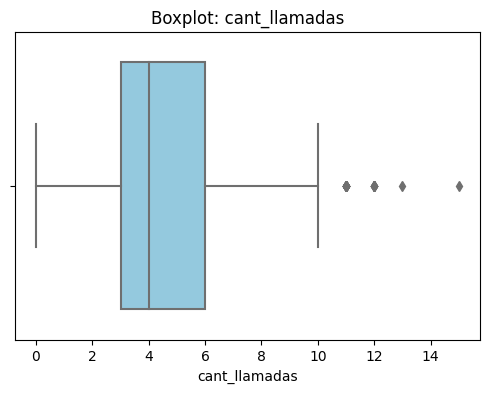

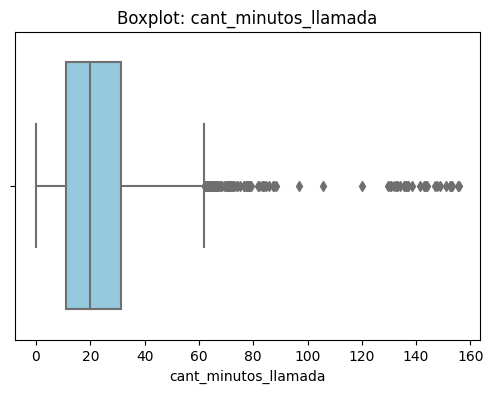

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers. Los bigotes del boxplot cubren todo el rango de datos sin puntos fuera de ellos, consistente con la distribución uniforme que vimos en el histograma.
- cant_mensajes: Si presenta outliers, todos del lado superior.
- cant_llamadas: Si presenta outliers, todos del lado superior.
- cant_minutos_llamada: Sí presenta outliers, todos del lado superior, y son los más numerosos y extremos de los tres — hay usuarios que acumulan hasta 160 minutos, muy por encima del resto.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col}: límite superior = {limite_superior:.2f} | máximo real = {user_profile[col].max()}")

cant_mensajes: límite superior = 11.50 | máximo real = 17.0
cant_llamadas: límite superior = 10.50 | máximo real = 15.0
cant_minutos_llamada: límite superior = 61.86 | máximo real = 155.69


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener. El máximo real (17) no está tan lejos del límite superior calculado por IQR, y la media (5.52) y mediana (5.00) son muy similares, señal de que la distribución no está muy distorsionada. Los valores altos representan usuarios que mandan más mensajes de lo típico, no errores de captura.
- cant_llamadas: mantener, mismo criterio. Media (4.48) y mediana (4.00) muy cercanas, y el máximo (15) es un valor razonable de comportamiento real, no un error.
- cant_minutos_llamada: mantener. Aquí sí hay más diferencia entre media (23.32) y mediana (19.78), lo que confirma el sesgo a la derecha que vimos en el histograma — pero el máximo (155.69) sigue siendo un valor plausible (acumulado de varias llamadas en el año), no un dato imposible. Son clientes con alto consumo de llamadas, información valiosa para segmentación.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

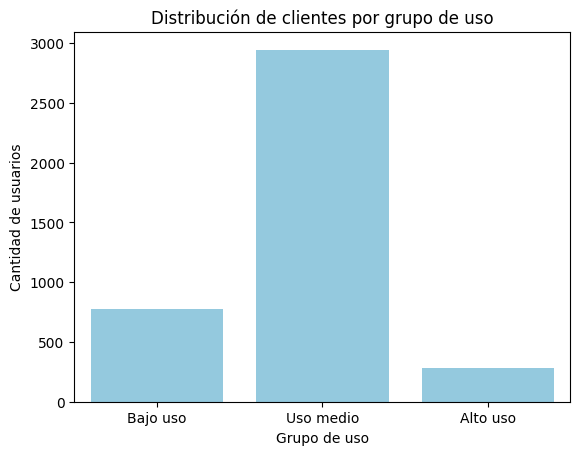

In [43]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], color='skyblue')
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

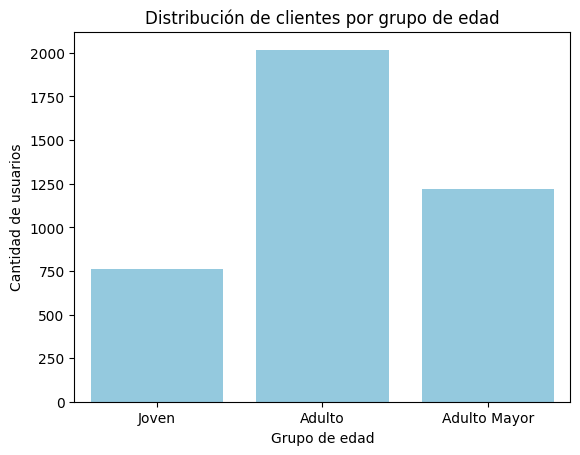

In [44]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], color='skyblue')
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ Problemas detectados en los datos
Sentinels numéricos y de texto: La columna age contenía un valor centinela de -999 que distorsionaba las métricas de tendencia central. Por su parte, la columna city presentaba el sentinel "?" en 96 registros, lo que equivale al 2.4% del total, además de 469 valores nulos explícitos correspondientes al 11.7%. En conjunto, esto sumaba cerca del 14.1% de registros con información de ciudad no utilizable en su forma original.

Inconsistencia temporal: Un total de 40 registros, que representan el 1% de los usuarios, tenían la variable reg_date con el año 2026. Esto queda fuera del rango válido del proyecto fijado hasta 2024, lo cual indica un probable error de captura.

Nulos estructurales vs. reales: Las columnas duration y length de la tabla de uso presentaban alrededor del 55% y 45% de nulos respectivamente. Sin embargo, se determinó mediante un análisis de dependencia con la variable type que son nulos tipo MAR, o perdidos al azar por sus siglas en inglés. Esto significa que son ausencias explicadas por el propio diseño del dataset, ya que una llamada no tiene longitud de mensaje y viceversa, por lo que no representan errores de calidad. Adicionalmente, se identificaron 28 registros, equivalentes al 0.07%, con inconsistencia entre el tipo y la columna de métrica poblada, los cuales fueron marcados para revisión.

Codificación de churn: El 88.35% de nulos en churn_date no representa un problema de calidad, sino que codifica a los clientes activos por la ausencia de una fecha de baja. Esta característica se aprovechó para derivar la variable binaria de estado.

🔍 Segmentos por Edad
Adulto (30-59 años): Es el segmento dominante con aproximadamente 2020 usuarios, lo que representa el 50.5% de la base.

Adulto Mayor (60+): Cuenta con cerca de 1220 usuarios, equivalente al 30.5%.

Joven (<30): Es el grupo minoritario con unos 760 usuarios que conforman el 19% restante.

La distribución de edad es prácticamente uniforme dentro del rango de 18 a 79 años, sin sesgo hacia ningún tramo etario específico ni relación aparente con la elección de plan. De hecho, la proporción entre los planes Básico y Premium se mantiene constante en todos los grupos de edad.

📊 Segmentos por Nivel de Uso
Uso medio: Concentra a la mayoría de los clientes con unos 2950 usuarios, es decir, el 73.75%.

Bajo uso: Agrupa a cerca de 780 usuarios que representan el 19.5%.

Alto uso: Es el segmento más pequeño con solo 280 usuarios, equivalentes al 7%.

Las variables de consumo, como la cantidad de mensajes, de llamadas y de minutos de llamada, muestran distribuciones con sesgo positivo o cola larga a la derecha. Al ser consistentes entre sí, esto sugiere que el comportamiento de alto consumo está correlacionado entre los distintos canales de uso; por ejemplo, un cliente que llama mucho también tiende a enviar más mensajes.

➡️ Conclusión: La base de clientes de ConnectaTel está compuesta mayoritariamente por usuarios de consumo moderado y edad adulta. Sin embargo, existen dos segmentos de interés estratégico en los extremos: un grupo pequeño pero significativo de alto consumo con potencial para realizar upselling, y un segmento de bajo uso que podría estar en riesgo de abandono debido a una baja percepción del valor del servicio. Una mala desición aquí podría costar clientes valiosos.

💎 Segmentos más valiosos para ConnectaTel
El segmento de Alto uso, con su 7% de la base, es el más valioso en términos de ingresos potenciales por consumo. Representa el objetivo ideal para ofertas de planes premium o servicios adicionales, dado que su comportamiento de uso intensivo ya está validado con datos.

El segmento Adulto de Uso medio es el más numeroso y estable, por lo que constituye la base de ingresos recurrentes de la empresa. Retener a este grupo debe ser prioritario dado su enorme peso en la cartera total de clientes.

📈 Patrones de uso extremo (outliers)
Se identificaron outliers superiores en la cantidad de mensajes, de llamadas y de minutos de llamada, todos concentrados en el extremo alto de la distribución. No se detectó ningún outlier del lado inferior, lo cual es coherente ya que estas variables no pueden tomar valores negativos.

El caso más notable es la cantidad de minutos de llamada, donde hay clientes que acumulan hasta 155.69 minutos frente a un límite superior IQR considerablemente menor. Esto se validó como un comportamiento real de clientes de alto consumo y no como un error al estraer o capturar la información.

Implicación para el negocio: Estos outliers no deben tratarse como ruido a eliminar, sino como una señal temprana de clientes de alto valor que podrían estar submonetizados con su plan actual, especialmente si se encuentran en el plan Básico.

💡 Recomendaciones
Plan intermedio o "Plus": Crear una opción intermedia entre Básico y Premium dirigida al segmento de Uso medio, que representa el 73.75% de la base. Actualmente estos usuarios podrían estar sobrepagando en Premium o limitados en Básico, por lo que esto optimizaría la relación precio-consumo.

Estrategia de upselling dirigida: Identificar proactivamente a los clientes del segmento de Alto uso que aún están en el plan Básico y ofrecerles la migración a Premium, apalancando el comportamiento de consumo ya evidenciado en los datos en lugar de lanzar campañas genéricas.

Retención focalizada en Bajo uso: Dado que este segmento representa un riesgo latente de churn, ya que el bajo consumo puede reflejar una baja percepción de valor, se recomienda investigar sus tasas de cancelación mediante la variable is_churned y diseñar incentivos de reactivación específicos.

Mejora en calidad de captura: Debido a que se detectaron sentinels como -999 y "?" junto a fechas fuera de rango en el proceso de ingesta, se recomienda reforzar la validación en el formulario de registro de usuarios. El objetivo es reducir el porcentaje de datos que requieren limpieza en futuros análisis.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`